In [95]:
import math
import numpy as np

def calc_bayes(p_h, p_he, p_hne):
    return (p_h*p_he)/((p_h*p_he)+(p_hne*(1-p_h)))

def dbinom(n_success: int, size: int, prob: float = 0.5) -> float:
    assert 0 <= prob <= 1, "p must be between 0 and 1"

    s = n_success
    f = size-n_success
    nk = math.factorial(size)/(math.factorial(s)*math.factorial(f))

    return nk*(prob**s)*((1-prob)**(f))

def grid_approx(n_success, n, n_points=30, prior="unif"):

    p_grid = np.linspace(0, 1, n_points)

    # define prior
    if prior == 'unif':
        prior = [1]*len(p_grid)
    elif prior == 'step':
        prior = [0 if x < 0.5 else 1 for x in p_grid]
    else:
        ValueError("Prior argument expected one of 'unif' or 'step'")

    #compute likelihood at each value in grid
    likelihood = [dbinom(n_success, n, prob=x) for x in p_grid]

    # compute product of likelihood and prior

    unstd_posterior = list(map(lambda x, y: x*y, likelihood, prior))

    # standardize the posterior, so it sums to 1
    posterior = [x / sum(unstd_posterior) for x in unstd_posterior]
    return p_grid, posterior

In [77]:
# Vampire example
calc_bayes(0.001, 0.95, 0.01)

0.08683729433272395

In [96]:
p_grid, posterior = grid_approx(6, 9, n_points=1000)

array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307, 0.07407

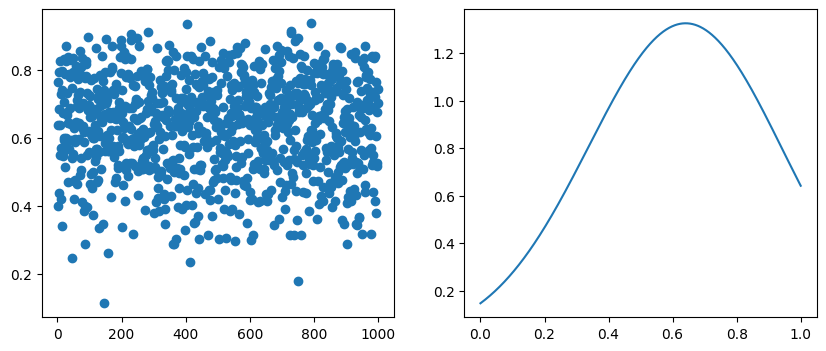

In [103]:
# Now we are going to sample from the grid approximation posterior

samples = np.random.choice(p_grid, size=1000, replace=True, p=posterior).reshape(-1,1)


# Recreate plot 3.1
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

# Initialize and fit the KDE model
kde = KernelDensity(kernel='gaussian', bandwidth='silverman').fit(samples)
log_dens = kde.score_samples(p_grid.reshape(-1,1))
dens = np.exp(log_dens)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

axs[0].scatter(list(range(1,1001)), y=samples)
axs[1].plot(p_grid, dens)
plt.show()

In [ ]:
samples = np.random.choice(p_grid, size=10000, replace=True, p=posterior).reshape(-1,1)

kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(samples)

x_plot = np.linspace(-4, 4, 1000).reshape(-1, 1)
log_dens = kde.score_samples(x_plot)
dens = np.exp(log_dens)

In [94]:
np.linspace(0, 1, 1000)

array([0.        , 0.001001  , 0.002002  , 0.003003  , 0.004004  ,
       0.00500501, 0.00600601, 0.00700701, 0.00800801, 0.00900901,
       0.01001001, 0.01101101, 0.01201201, 0.01301301, 0.01401401,
       0.01501502, 0.01601602, 0.01701702, 0.01801802, 0.01901902,
       0.02002002, 0.02102102, 0.02202202, 0.02302302, 0.02402402,
       0.02502503, 0.02602603, 0.02702703, 0.02802803, 0.02902903,
       0.03003003, 0.03103103, 0.03203203, 0.03303303, 0.03403403,
       0.03503504, 0.03603604, 0.03703704, 0.03803804, 0.03903904,
       0.04004004, 0.04104104, 0.04204204, 0.04304304, 0.04404404,
       0.04504505, 0.04604605, 0.04704705, 0.04804805, 0.04904905,
       0.05005005, 0.05105105, 0.05205205, 0.05305305, 0.05405405,
       0.05505506, 0.05605606, 0.05705706, 0.05805806, 0.05905906,
       0.06006006, 0.06106106, 0.06206206, 0.06306306, 0.06406406,
       0.06506507, 0.06606607, 0.06706707, 0.06806807, 0.06906907,
       0.07007007, 0.07107107, 0.07207207, 0.07307307, 0.07407

In [85]:
# Sample data
X = np.array([-1, -2, -3, 1, 2, 3]).reshape(-1, 1)
X

array([[-1],
       [-2],
       [-3],
       [ 1],
       [ 2],
       [ 3]])